# Initialization & Data Preparation

### Set seed and load data

In [17]:
from pathlib import Path

import pandas as pd

seed = 42

candidate_paths = [
    Path("ticketmaster_processed_english.csv"),
    Path("ECE569A/Course_Project/ticketmaster_processed_english.csv"),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Could not find ticketmaster_processed_english.csv. "
        "Run the notebook from the course-project folder or the workspace root."
    )

df = pd.read_csv(data_path)

print("Loaded:", data_path)
print("Shape:", df.shape)
df.head()


Loaded: ticketmaster_processed_english.csv
Shape: (16338, 19)


,subject,body,combined_text,type,priority,queue,language,tag_1,tag_2,answer,text_char_len,text_word_len,version,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Account Disruption Dear Customer Support Team,...",Incident,high,Technical Support,en,Account,Disruption,"Thank you for reaching out, <name>. We are awa...",563,84,51,Outage,IT,Tech Support,NaN,NaN,NaN
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Query About Smart Home System Integration Feat...,Request,medium,Returns and Exchanges,en,Product,Feature,Thank you for your inquiry. Our products suppo...,585,83,51,Tech Support,NaN,NaN,NaN,NaN,NaN
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Inquiry Regarding Invoice Details Dear Custome...,Request,low,Billing and Payments,en,Billing,Payment,We appreciate you reaching out with your billi...,639,95,51,Account,Documentation,Feedback,NaN,NaN,NaN
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Question About Marketing Agency Software Compa...,Problem,medium,Sales and Pre-Sales,en,Product,Feature,Thank you for your inquiry. Our product suppor...,732,103,51,Feedback,Tech Support,NaN,NaN,NaN,NaN
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...","Feature Query Dear Customer Support,\n\nI hope...",Request,high,Technical Support,en,Feature,Product,Thank you for your inquiry. Please specify whi...,660,99,51,Documentation,Feedback,NaN,NaN,NaN,NaN


### Extract Data to Form X and Responses y1, y2, and y3


In [18]:
X = df["combined_text"]
y1 = df["type"]
y2 = df["priority"]
y3 = df["queue"]

print("X shape:", X.shape)
print("y1 type shape:", y1.shape)
print("y2 priority shape:", y2.shape)
print("y3 queue shape:", y3.shape)


X shape: (16338,)
y1 type shape: (16338,)
y2 priority shape: (16338,)
y3 queue shape: (16338,)


### TF-IDF Fitting Setting

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

# These parameters are passed into a Pipeline so TF-IDF is fit only on the
# appropriate training fold during cross-validation.
tfidf_params = {
    "max_features": 15000,
    "ngram_range": (1, 2),
    "min_df": 2,
}

print("TF-IDF parameters:", tfidf_params)


TF-IDF parameters: {'max_features': 15000, 'ngram_range': (1, 2), 'min_df': 2}


### Stratified Train-Test Split


In [20]:
from sklearn.model_selection import train_test_split

test_size = 0.2

# Separate stratified splits are used because each prediction task has a different target distribution.
# TF-IDF is intentionally not fit here; it is fit inside each model Pipeline.
X_train_text_y1, X_test_text_y1, y1_train, y1_test = train_test_split(
    X, y1,
    test_size=test_size,
    random_state=seed,
    stratify=y1,
)

X_train_text_y2, X_test_text_y2, y2_train, y2_test = train_test_split(
    X, y2,
    test_size=test_size,
    random_state=seed,
    stratify=y2,
)

X_train_text_y3, X_test_text_y3, y3_train, y3_test = train_test_split(
    X, y3,
    test_size=test_size,
    random_state=seed,
    stratify=y3,
)

print("y1/type train-test shapes:", X_train_text_y1.shape, X_test_text_y1.shape, y1_train.shape, y1_test.shape)
print("y2/priority train-test shapes:", X_train_text_y2.shape, X_test_text_y2.shape, y2_train.shape, y2_test.shape)
print("y3/queue train-test shapes:", X_train_text_y3.shape, X_test_text_y3.shape, y3_train.shape, y3_test.shape)


y1/type train-test shapes: (13070,) (3268,) (13070,) (3268,)
y2/priority train-test shapes: (13070,) (3268,) (13070,) (3268,)
y3/queue train-test shapes: (13070,) (3268,) (13070,) (3268,)


# SVM (Predicting y1, Type)


### Kernel SVM Tuning for Type
- Use RandomizedSearchCV for hyperparameter tuning
- Random search selection strategy: weighted F1 score, scoring="f1_weighted"
- Use 3-fold stratified CV
- Search both class_weight=None and class_weight="balanced" to compare unweighted and cost-sensitive training

In [21]:
from scipy.stats import loguniform
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=seed,
)

param_distributions = {
    # Third pass: exploit the best region from the previous run.
    "svm__C": loguniform(5e1, 2e2),
    "svm__gamma": loguniform(5e-3, 1.5e-2),
    "svm__kernel": ["rbf"],
    "svm__class_weight": [None, "balanced"],
}

kernel_svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_params)),
    ("svm", SVC(
        C=1.0,
        kernel="rbf",
        gamma="scale",
        degree=3,
        class_weight=None,
        probability=False,
        max_iter=-1,
        cache_size=2000,
    )),
])

random_search_y1 = RandomizedSearchCV(
    estimator=kernel_svm_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="f1_weighted",
    cv=cv,
    random_state=seed,
    n_jobs=-1,
    verbose=2,
)

random_search_y1.fit(X_train_text_y1, y1_train)

print("Best CV weighted F1:", random_search_y1.best_score_)
print("Best parameters:", random_search_y1.best_params_)

best_svm_y1 = random_search_y1.best_estimator_
y1_pred = best_svm_y1.predict(X_test_text_y1)

print("Test accuracy:", accuracy_score(y1_test, y1_pred))
print("Test weighted F1:", f1_score(y1_test, y1_pred, average="weighted"))
print(classification_report(y1_test, y1_pred))


Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END svm__C=147.36378278199413, svm__class_weight=None, svm__gamma=0.005934850914813898, svm__kernel=rbf; total time=  37.7s
[CV] END svm__C=147.36378278199413, svm__class_weight=None, svm__gamma=0.005934850914813898, svm__kernel=rbf; total time=  37.9s
[CV] END svm__C=147.36378278199413, svm__class_weight=None, svm__gamma=0.005934850914813898, svm__kernel=rbf; total time=  38.2s
[CV] END svm__C=62.070903057429355, svm__class_weight=None, svm__gamma=0.008281088231655272, svm__kernel=rbf; total time=  38.6s
[CV] END svm__C=84.0360488869519, svm__class_weight=None, svm__gamma=0.006116326228088529, svm__kernel=rbf; total time=  38.7s
[CV] END svm__C=84.0360488869519, svm__class_weight=None, svm__gamma=0.006116326228088529, svm__kernel=rbf; total time=  39.1s
[CV] END svm__C=84.0360488869519, svm__class_weight=None, svm__gamma=0.006116326228088529, svm__kernel=rbf; total time=  39.2s
[CV] END svm__C=62.070903057429355, svm__c

### Confusion Matrix for y1 Type Predictions

Confusion matrix counts: rows=true labels, columns=predicted labels


,Change,Incident,Problem,Request
Change,336,0,0,5
Incident,0,1148,166,0
Problem,0,213,466,1
Request,0,1,0,932


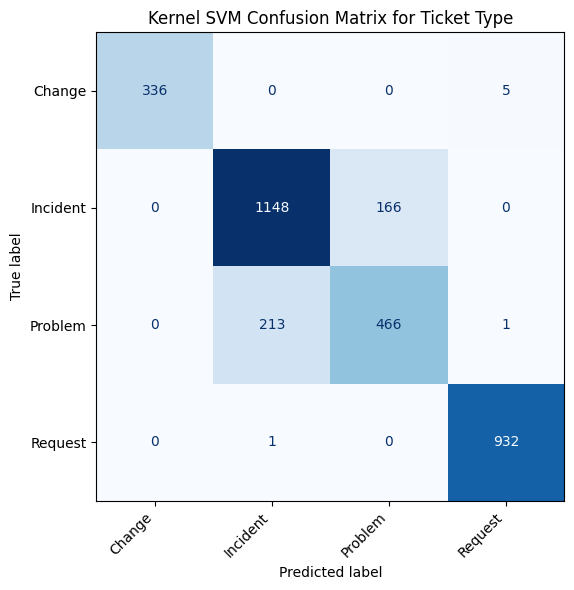

In [22]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

labels = sorted(y1_test.unique())
cm = confusion_matrix(y1_test, y1_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print("Confusion matrix counts: rows=true labels, columns=predicted labels")
display(cm_df)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Kernel SVM Confusion Matrix for Ticket Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Linear SVM Tuning for Type

In [23]:
from scipy.stats import loguniform
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

cv_linear_y1 = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=seed,
)

param_distributions_linear_y1 = {
    "svm__C": loguniform(1e-3, 1e2),
    "svm__class_weight": [None, "balanced"],
}

linear_svm_pipeline_y1 = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_params)),
    ("svm", LinearSVC(
        dual="auto",
        max_iter=10000,
        random_state=seed,
    )),
])

random_search_linear_y1 = RandomizedSearchCV(
    estimator=linear_svm_pipeline_y1,
    param_distributions=param_distributions_linear_y1,
    n_iter=30,
    scoring="f1_weighted",
    cv=cv_linear_y1,
    random_state=seed,
    n_jobs=-1,
    verbose=2,
)

random_search_linear_y1.fit(X_train_text_y1, y1_train)

print("Best CV macro F1:", random_search_linear_y1.best_score_)
print("Best parameters:", random_search_linear_y1.best_params_)

best_linear_svm_y1 = random_search_linear_y1.best_estimator_
y1_linear_pred = best_linear_svm_y1.predict(X_test_text_y1)

print("Test accuracy:", accuracy_score(y1_test, y1_linear_pred))
print("Test weighted F1:", f1_score(y1_test, y1_linear_pred, average="weighted"))
print(classification_report(y1_test, y1_linear_pred))


Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END ..svm__C=0.0745934328572655, svm__class_weight=None; total time=   1.2s
[CV] END ..svm__C=0.0745934328572655, svm__class_weight=None; total time=   1.2s
[CV] END ..svm__C=0.0745934328572655, svm__class_weight=None; total time=   1.2s
[CV] END svm__C=0.008263688714158009, svm__class_weight=balanced; total time=   1.3s
[CV] END svm__C=0.008263688714158009, svm__class_weight=balanced; total time=   1.3s
[CV] END svm__C=0.008263688714158009, svm__class_weight=balanced; total time=   1.3s
[CV] END ..svm__C=0.9846738873614566, svm__class_weight=None; total time=   1.3s
[CV] END ..svm__C=0.9846738873614566, svm__class_weight=None; total time=   1.3s
[CV] END .svm__C=0.16949768237884735, svm__class_weight=None; total time=   1.2s
[CV] END .svm__C=0.16949768237884735, svm__class_weight=None; total time=   1.3s
[CV] END svm__C=0.0019517224641449498, svm__class_weight=balanced; total time=   1.3s
[CV] END .svm__C=0.169497682378

### Confusion Matrix for Linear SVM y1 Type Predictions


Confusion matrix counts: rows=true labels, columns=predicted labels


,Change,Incident,Problem,Request
Change,335,0,2,4
Incident,1,1128,185,0
Problem,1,177,501,1
Request,0,0,1,932


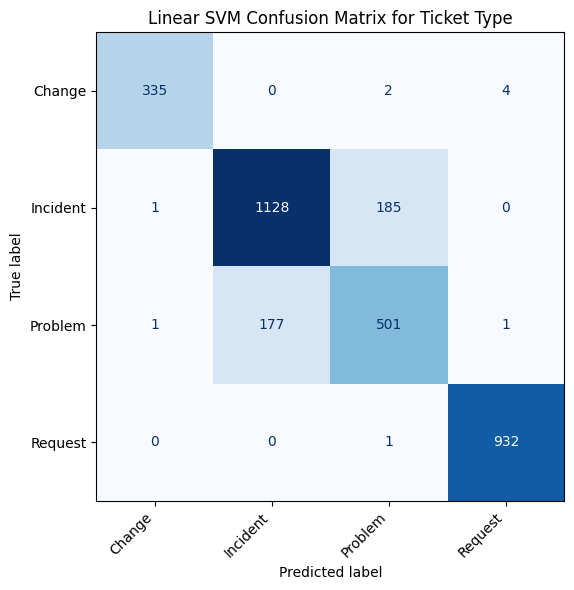

In [24]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

labels_linear_y1 = sorted(y1_test.unique())
cm_linear_y1 = confusion_matrix(y1_test, y1_linear_pred, labels=labels_linear_y1)
cm_linear_y1_df = pd.DataFrame(cm_linear_y1, index=labels_linear_y1, columns=labels_linear_y1)

print("Confusion matrix counts: rows=true labels, columns=predicted labels")
display(cm_linear_y1_df)

disp_linear_y1 = ConfusionMatrixDisplay(confusion_matrix=cm_linear_y1, display_labels=labels_linear_y1)
fig, ax = plt.subplots(figsize=(7, 6))
disp_linear_y1.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Linear SVM Confusion Matrix for Ticket Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# SVM (Predicting y2, Priority)

### Kernel SVM Tuning for Priority
- Replicate the y1 Kernel SVM workflow for y2 priority labels
- Use RandomizedSearchCV with 3-fold stratified CV
- Select hyperparameters using macro F1 score to treat high, medium, and low priority equally
- Broaden C and gamma because priority did not perform well with the y1-focused range

In [25]:
from scipy.stats import loguniform
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

cv_y2 = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=seed,
)

param_distributions_y2 = {
    "svm__C": loguniform(1e0, 5e2),
    "svm__gamma": loguniform(5e-4, 5e-2),
    "svm__kernel": ["rbf"],
    "svm__class_weight": [None, "balanced"],
}

kernel_svm_pipeline_y2 = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_params)),
    ("svm", SVC(
        C=1.0,
        kernel="rbf",
        gamma="scale",
        degree=3,
        class_weight=None,
        probability=False,
        max_iter=-1,
        cache_size=2000,
    )),
])

random_search_y2 = RandomizedSearchCV(
    estimator=kernel_svm_pipeline_y2,
    param_distributions=param_distributions_y2,
    n_iter=30,
    scoring="f1_macro",
    cv=cv_y2,
    random_state=seed,
    n_jobs=-1,
    verbose=2,
)

random_search_y2.fit(X_train_text_y2, y2_train)

print("Best CV macro F1:", random_search_y2.best_score_)
print("Best parameters:", random_search_y2.best_params_)

best_svm_y2 = random_search_y2.best_estimator_
y2_pred = best_svm_y2.predict(X_test_text_y2)

print("Test accuracy:", accuracy_score(y2_test, y2_pred))
print("Test weighted F1:", f1_score(y2_test, y2_pred, average="weighted"))
print(classification_report(y2_test, y2_pred))


Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END svm__C=127.16354381031323, svm__class_weight=None, svm__gamma=0.0010256691315437248, svm__kernel=rbf; total time= 1.4min
[CV] END svm__C=127.16354381031323, svm__class_weight=None, svm__gamma=0.0010256691315437248, svm__kernel=rbf; total time= 1.4min
[CV] END svm__C=127.16354381031323, svm__class_weight=None, svm__gamma=0.0010256691315437248, svm__kernel=rbf; total time= 1.4min
[CV] END svm__C=2.636480303843164, svm__class_weight=None, svm__gamma=0.004144458433442569, svm__kernel=rbf; total time= 1.4min
[CV] END svm__C=2.636480303843164, svm__class_weight=None, svm__gamma=0.004144458433442569, svm__kernel=rbf; total time= 1.4min
[CV] END svm__C=10.253509690168487, svm__class_weight=None, svm__gamma=0.0011636961140314352, svm__kernel=rbf; total time= 1.4min
[CV] END svm__C=10.253509690168487, svm__class_weight=None, svm__gamma=0.0011636961140314352, svm__kernel=rbf; total time= 1.4min
[CV] END svm__C=10.25350969016848

### Confusion Matrix for y2 Priority Predictions

Confusion matrix counts: rows=true labels, columns=predicted labels


,high,low,medium
high,895,120,254
low,113,415,147
medium,297,173,854


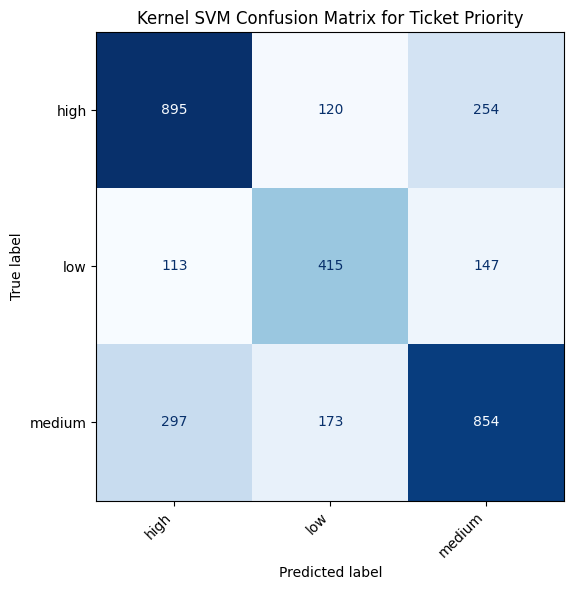

In [26]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

labels_y2 = sorted(y2_test.unique())
cm_y2 = confusion_matrix(y2_test, y2_pred, labels=labels_y2)
cm_y2_df = pd.DataFrame(cm_y2, index=labels_y2, columns=labels_y2)

print("Confusion matrix counts: rows=true labels, columns=predicted labels")
display(cm_y2_df)

disp_y2 = ConfusionMatrixDisplay(confusion_matrix=cm_y2, display_labels=labels_y2)
fig, ax = plt.subplots(figsize=(7, 6))
disp_y2.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Kernel SVM Confusion Matrix for Ticket Priority")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Linear SVM Tuning for Priority

In [27]:
from scipy.stats import loguniform
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

cv_linear_y2 = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=seed,
)

param_distributions_linear_y2 = {
    "svm__C": loguniform(1e-3, 1e2),
    "svm__class_weight": [None, "balanced"],
}

linear_svm_pipeline_y2 = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_params)),
    ("svm", LinearSVC(
        dual="auto",
        max_iter=10000,
        random_state=seed,
    )),
])

random_search_linear_y2 = RandomizedSearchCV(
    estimator=linear_svm_pipeline_y2,
    param_distributions=param_distributions_linear_y2,
    n_iter=30,
    scoring="f1_macro",
    cv=cv_linear_y2,
    random_state=seed,
    n_jobs=-1,
    verbose=2,
)

random_search_linear_y2.fit(X_train_text_y2, y2_train)

print("Best CV macro F1:", random_search_linear_y2.best_score_)
print("Best parameters:", random_search_linear_y2.best_params_)

best_linear_svm_y2 = random_search_linear_y2.best_estimator_
y2_linear_pred = best_linear_svm_y2.predict(X_test_text_y2)

print("Test accuracy:", accuracy_score(y2_test, y2_linear_pred))
print("Test macro F1:", f1_score(y2_test, y2_linear_pred, average="macro"))
print("Test weighted F1:", f1_score(y2_test, y2_linear_pred, average="weighted"))
print(classification_report(y2_test, y2_linear_pred))


Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END svm__C=0.008263688714158009, svm__class_weight=balanced; total time=   1.2s
[CV] END ..svm__C=0.0745934328572655, svm__class_weight=None; total time=   1.4s
[CV] END svm__C=0.008263688714158009, svm__class_weight=balanced; total time=   1.4s
[CV] END ..svm__C=0.0745934328572655, svm__class_weight=None; total time=   1.4s
[CV] END ..svm__C=0.0745934328572655, svm__class_weight=None; total time=   1.4s
[CV] END svm__C=0.008263688714158009, svm__class_weight=balanced; total time=   1.4s
[CV] END ..svm__C=0.9846738873614566, svm__class_weight=None; total time=   1.6s
[CV] END ..svm__C=0.9846738873614566, svm__class_weight=None; total time=   1.7s
[CV] END svm__C=0.0019517224641449498, svm__class_weight=balanced; total time=   1.3s
[CV] END .svm__C=0.16949768237884735, svm__class_weight=None; total time=   1.4s
[CV] END svm__C=0.0019517224641449498, svm__class_weight=balanced; total time=   1.3s
[CV] END .svm__C=0.1694976

### Confusion Matrix for Linear SVM y2 Priority Predictions


Confusion matrix counts: rows=true labels, columns=predicted labels


,high,low,medium
high,899,101,269
low,106,412,157
medium,262,143,919


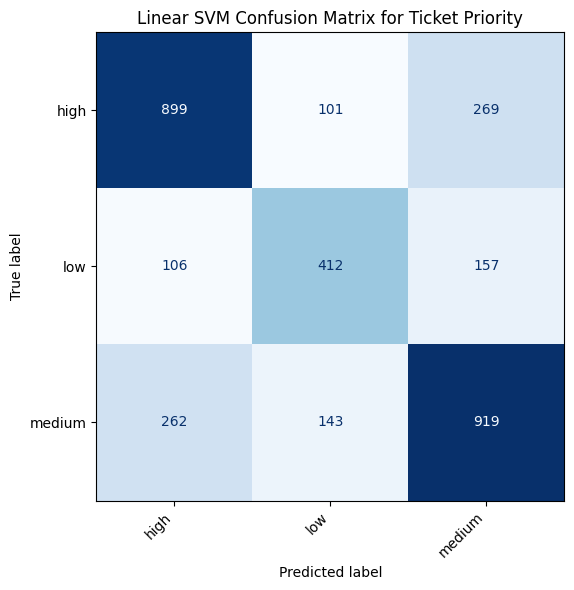

In [28]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

labels_linear_y2 = sorted(y2_test.unique())
cm_linear_y2 = confusion_matrix(y2_test, y2_linear_pred, labels=labels_linear_y2)
cm_linear_y2_df = pd.DataFrame(cm_linear_y2, index=labels_linear_y2, columns=labels_linear_y2)

print("Confusion matrix counts: rows=true labels, columns=predicted labels")
display(cm_linear_y2_df)

disp_linear_y2 = ConfusionMatrixDisplay(confusion_matrix=cm_linear_y2, display_labels=labels_linear_y2)
fig, ax = plt.subplots(figsize=(7, 6))
disp_linear_y2.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Linear SVM Confusion Matrix for Ticket Priority")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# SVM (Predicting y3, Queue)


### Kernel SVM Tuning for Queue


In [29]:
from scipy.stats import loguniform
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

cv_y3 = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=seed,
)

param_distributions_y3 = {
    "svm__C": loguniform(1e0, 5e2),
    "svm__gamma": loguniform(5e-4, 5e-2),
    "svm__kernel": ["rbf"],
    "svm__class_weight": [None, "balanced"],
}

kernel_svm_pipeline_y3 = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_params)),
    ("svm", SVC(
        C=1.0,
        kernel="rbf",
        gamma="scale",
        degree=3,
        class_weight=None,
        probability=False,
        max_iter=-1,
        cache_size=2000,
    )),
])

random_search_y3 = RandomizedSearchCV(
    estimator=kernel_svm_pipeline_y3,
    param_distributions=param_distributions_y3,
    n_iter=30,
    scoring="f1_macro",
    cv=cv_y3,
    random_state=seed,
    n_jobs=-1,
    verbose=2,
)

random_search_y3.fit(X_train_text_y3, y3_train)

print("Best CV macro F1:", random_search_y3.best_score_)
print("Best parameters:", random_search_y3.best_params_)

best_svm_y3 = random_search_y3.best_estimator_
y3_pred = best_svm_y3.predict(X_test_text_y3)

print("Test accuracy:", accuracy_score(y3_test, y3_pred))
print("Test weighted F1:", f1_score(y3_test, y3_pred, average="weighted"))
print(classification_report(y3_test, y3_pred))


Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END svm__C=127.16354381031323, svm__class_weight=None, svm__gamma=0.0010256691315437248, svm__kernel=rbf; total time= 1.7min
[CV] END svm__C=127.16354381031323, svm__class_weight=None, svm__gamma=0.0010256691315437248, svm__kernel=rbf; total time= 1.7min
[CV] END svm__C=127.16354381031323, svm__class_weight=None, svm__gamma=0.0010256691315437248, svm__kernel=rbf; total time= 1.7min
[CV] END svm__C=10.253509690168487, svm__class_weight=None, svm__gamma=0.0011636961140314352, svm__kernel=rbf; total time= 1.8min
[CV] END svm__C=10.253509690168487, svm__class_weight=None, svm__gamma=0.0011636961140314352, svm__kernel=rbf; total time= 1.8min
[CV] END svm__C=2.636480303843164, svm__class_weight=None, svm__gamma=0.004144458433442569, svm__kernel=rbf; total time= 1.8min
[CV] END svm__C=10.253509690168487, svm__class_weight=None, svm__gamma=0.0011636961140314352, svm__kernel=rbf; total time= 1.8min
[CV] END svm__C=2.6364803038431

### Confusion Matrix for y3 Queue Predictions


Confusion matrix counts: rows=true labels, columns=predicted labels


,Billing and Payments,Customer Service,General Inquiry,Human Resources,IT Support,Product Support,Returns and Exchanges,Sales and Pre-Sales,Service Outages and Maintenance,Technical Support
Billing and Payments,277,17,0,0,6,12,0,0,1,6
Customer Service,19,324,0,0,24,51,2,3,4,55
General Inquiry,0,7,28,0,2,4,0,0,0,6
Human Resources,0,6,0,45,6,7,1,0,0,5
IT Support,4,31,1,1,244,31,1,1,1,73
Product Support,11,71,0,2,34,362,5,5,3,122
Returns and Exchanges,7,17,0,0,6,25,90,4,0,15
Sales and Pre-Sales,1,16,0,0,1,10,1,65,0,9
Service Outages and Maintenance,2,4,0,0,7,6,0,0,100,14
Technical Support,14,99,1,3,97,115,7,3,7,601


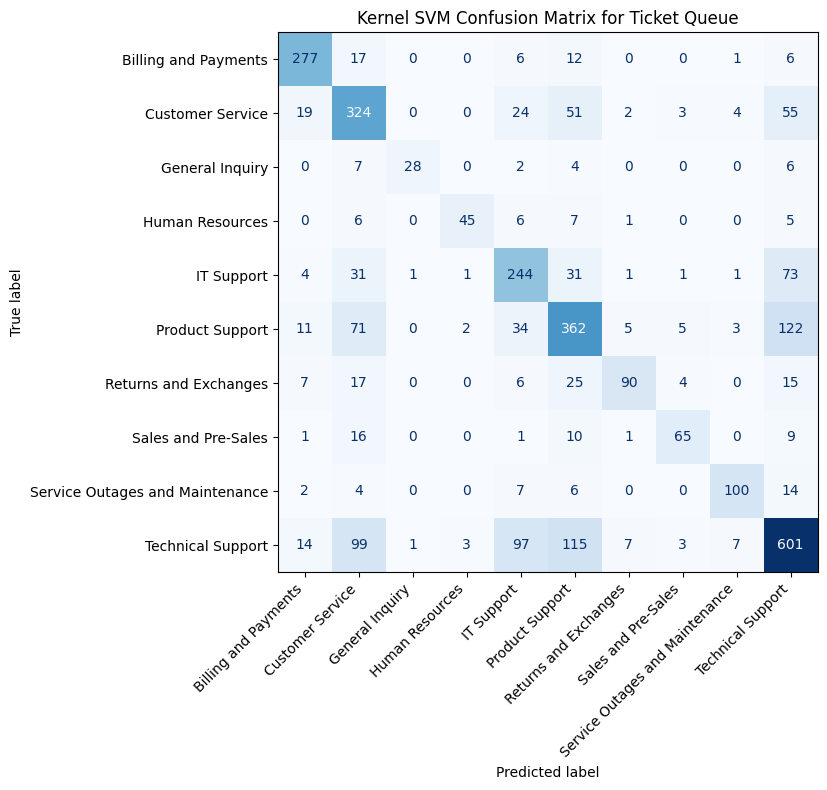

In [30]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

labels_y3 = sorted(y3_test.unique())
cm_y3 = confusion_matrix(y3_test, y3_pred, labels=labels_y3)
cm_y3_df = pd.DataFrame(cm_y3, index=labels_y3, columns=labels_y3)

print("Confusion matrix counts: rows=true labels, columns=predicted labels")
display(cm_y3_df)

disp_y3 = ConfusionMatrixDisplay(confusion_matrix=cm_y3, display_labels=labels_y3)
fig, ax = plt.subplots(figsize=(10, 8))
disp_y3.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Kernel SVM Confusion Matrix for Ticket Queue")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Linear SVM Tuning for Queue

In [31]:
from scipy.stats import loguniform
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

cv_linear_y3 = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=seed,
)

param_distributions_linear_y3 = {
    "svm__C": loguniform(1e-3, 1e2),
    "svm__class_weight": [None, "balanced"],
}

linear_svm_pipeline_y3 = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_params)),
    ("svm", LinearSVC(
        dual="auto",
        max_iter=10000,
        random_state=seed,
    )),
])

random_search_linear_y3 = RandomizedSearchCV(
    estimator=linear_svm_pipeline_y3,
    param_distributions=param_distributions_linear_y3,
    n_iter=30,
    scoring="f1_macro",
    cv=cv_linear_y3,
    random_state=seed,
    n_jobs=-1,
    verbose=2,
)

random_search_linear_y3.fit(X_train_text_y3, y3_train)

print("Best CV macro F1:", random_search_linear_y3.best_score_)
print("Best parameters:", random_search_linear_y3.best_params_)

best_linear_svm_y3 = random_search_linear_y3.best_estimator_
y3_linear_pred = best_linear_svm_y3.predict(X_test_text_y3)

print("Test accuracy:", accuracy_score(y3_test, y3_linear_pred))
print("Test macro F1:", f1_score(y3_test, y3_linear_pred, average="macro"))
print("Test weighted F1:", f1_score(y3_test, y3_linear_pred, average="weighted"))
print(classification_report(y3_test, y3_linear_pred))


Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END ..svm__C=0.0745934328572655, svm__class_weight=None; total time=   1.6s
[CV] END ..svm__C=0.0745934328572655, svm__class_weight=None; total time=   1.6s
[CV] END ..svm__C=0.0745934328572655, svm__class_weight=None; total time=   1.6s
[CV] END svm__C=0.008263688714158009, svm__class_weight=balanced; total time=   1.6s
[CV] END svm__C=0.008263688714158009, svm__class_weight=balanced; total time=   1.6s
[CV] END svm__C=0.008263688714158009, svm__class_weight=balanced; total time=   1.6s
[CV] END ..svm__C=0.9846738873614566, svm__class_weight=None; total time=   1.9s
[CV] END ..svm__C=0.9846738873614566, svm__class_weight=None; total time=   1.9s
[CV] END svm__C=0.0019517224641449498, svm__class_weight=balanced; total time=   1.4s
[CV] END svm__C=0.0019517224641449498, svm__class_weight=balanced; total time=   1.4s
[CV] END .svm__C=0.16949768237884735, svm__class_weight=None; total time=   1.6s
[CV] END .svm__C=0.1694976

### Confusion Matrix for Linear SVM y3 Queue Predictions


Confusion matrix counts: rows=true labels, columns=predicted labels


,Billing and Payments,Customer Service,General Inquiry,Human Resources,IT Support,Product Support,Returns and Exchanges,Sales and Pre-Sales,Service Outages and Maintenance,Technical Support
Billing and Payments,272,15,0,0,8,11,1,2,1,9
Customer Service,13,306,0,2,29,46,9,7,5,65
General Inquiry,0,6,28,0,1,4,0,1,1,6
Human Resources,0,0,1,44,8,7,4,1,0,5
IT Support,4,19,2,4,231,38,4,3,11,72
Product Support,13,54,4,4,34,363,17,7,4,115
Returns and Exchanges,8,13,0,2,6,18,98,4,0,15
Sales and Pre-Sales,1,15,0,0,2,7,2,66,0,10
Service Outages and Maintenance,1,3,0,1,10,6,1,0,103,8
Technical Support,12,87,5,6,88,97,17,14,11,610


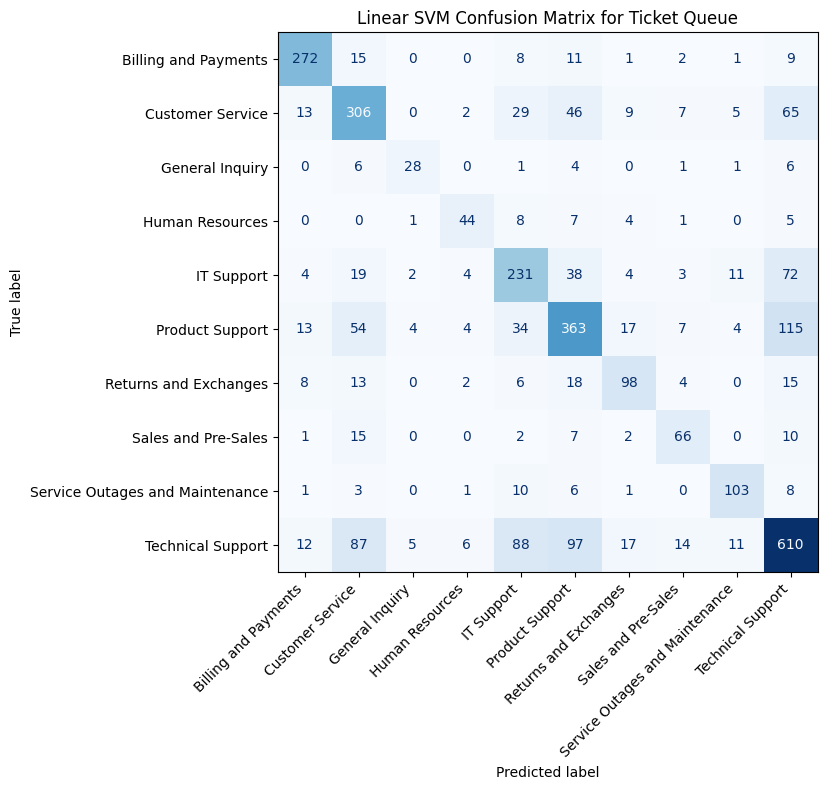

In [32]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

labels_linear_y3 = sorted(y3_test.unique())
cm_linear_y3 = confusion_matrix(y3_test, y3_linear_pred, labels=labels_linear_y3)
cm_linear_y3_df = pd.DataFrame(cm_linear_y3, index=labels_linear_y3, columns=labels_linear_y3)

print("Confusion matrix counts: rows=true labels, columns=predicted labels")
display(cm_linear_y3_df)

disp_linear_y3 = ConfusionMatrixDisplay(confusion_matrix=cm_linear_y3, display_labels=labels_linear_y3)
fig, ax = plt.subplots(figsize=(10, 8))
disp_linear_y3.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Linear SVM Confusion Matrix for Ticket Queue")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
